# Employee Turnover — Exploratory Data Analysis

This notebook examines data quality, employee turnover, missingness, source shift, numerical and categorical associations, and within-employee changes.

**Outcome definition used here:** keep the supplied `leave_ind`. Aziva code 41 in files 1–2 and code 42 in file 3 describe the same resignation outcome, but Aziva fields are outcome metadata and must not be used as model features.

Files 1 and 2 are the future training sources; file 3 remains the external test source. This notebook is exploratory and does not fit a predictive model.

## 1. Setup and data loading

The three files are loaded with their correct header rows. A source prefix is added to employee IDs so IDs from different files cannot collide. File 3's duplicate `target` column is checked against `leave_ind` before removal.

In [15]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "data").exists():
    raise FileNotFoundError("Run this notebook from the repository root or notebooks/ directory.")

DATASETS = {
    "file1": (ROOT / "data" / "file1.xlsx", 0),
    "file2": (ROOT / "data" / "file2.xlsx", 0),
    "file3": (ROOT / "data" / "file3.xlsx", 1),
}

frames = []
for source, (path, header) in DATASETS.items():
    frame = pd.read_excel(path, header=header)
    if "target" in frame.columns:
        assert frame["target"].equals(frame["leave_ind"]), "file3 target differs from leave_ind"
        frame = frame.drop(columns="target")
    frame["source"] = source
    frame["fictive_id"] = source + "_" + frame["fictive_employee"].astype(str)
    frames.append(frame)

united_df = pd.concat(frames, ignore_index=True)
united_df = united_df.rename(columns={
    "TeurGroupHscm": "contract_type",
    "EMP_Matzav_Mishpachti": "marital_status",
    "שינוי השכר בשקלים": "salary_change",
})
# Canonicalize equivalent labels before categorical and source-shift tests.
united_df["gender"] = united_df["gender"].replace({
    "גבר": "Male", "זכר": "Male", "אישה": "Female", "נקבה": "Female",
})
united_df["contract_type"] = united_df["contract_type"].replace({
    "גלובלי": "Global", "חודשי גלובלי": "Global", "חודשי": "Monthly",
    "שעתי": "Hourly", "עובד חיצוני": "External",
})
united_df["marital_status"] = united_df["marital_status"].replace({
    "נשוי/נשואה": "Married", "רווק/ה": "Single",
    "גרוש/ה": "Divorced", "אלמן/ה": "Widowed",
})
united_df["leave_ind"] = united_df["leave_ind"].astype(int)

display(pd.DataFrame({
    "rows": united_df.groupby("source").size(),
    "employees": united_df.groupby("source")["fictive_id"].nunique(),
    "periods_per_employee": united_df.groupby("source").size() / united_df.groupby("source")["fictive_id"].nunique(),
}))

,rows,employees,periods_per_employee
source,,,
file1,4420,1296,3.4105
file2,8792,2611,3.3673
file3,3147,793,3.9685


## 2. Target and Aziva integrity audit

This is a **data-integrity check**, not a hypothesis test. It verifies the one-way rule that every positive target row has the expected source-specific resignation code. It also counts code-bearing rows labelled zero; these may be earlier periods before the 12-month outcome window and are why the target must not be rebuilt from the code.

In [16]:
expected_code = united_df["source"].map({"file1": 41, "file2": 41, "file3": 42})
positive = united_df["leave_ind"].eq(1)
expected_code_present = united_df["aziva_kod"].eq(expected_code)

target_audit = []
for source, group in united_df.groupby("source"):
    expected = 41 if source in {"file1", "file2"} else 42
    target_audit.append({
        "source": source,
        "positive_rows": int(group["leave_ind"].sum()),
        "expected_code_rows": int(group["aziva_kod"].eq(expected).sum()),
        "positive_rows_with_expected_code": int(
            (group["leave_ind"].eq(1) & group["aziva_kod"].eq(expected)).sum()
        ),
        "expected_code_but_target_0": int(
            (group["leave_ind"].eq(0) & group["aziva_kod"].eq(expected)).sum()
        ),
    })

target_audit = pd.DataFrame(target_audit)
display(target_audit)
assert (united_df.loc[positive, "aziva_kod"].to_numpy() == expected_code.loc[positive].to_numpy()).all()

leakage_columns = [
    "aziva_kod", "aziva_date", "aziva_year", "fictive_employee", "fictive_id", "source"
]
print("Outcome/identifier columns excluded from future model features:", leakage_columns)

,source,positive_rows,expected_code_rows,positive_rows_with_expected_code,expected_code_but_target_0
0,file1,346,628,346,282
1,file2,698,1398,698,700
2,file3,153,311,153,158


Outcome/identifier columns excluded from future model features: ['aziva_kod', 'aziva_date', 'aziva_year', 'fictive_employee', 'fictive_id', 'source']


**Interpretation.** All 1,197 positive rows have the correct resignation code: 41 in files 1–2 and 42 in file 3. The reverse is not true: 1,140 earlier rows carry the eventual resignation code while `leave_ind=0`. This confirms that Aziva fields describe the outcome but cannot be used to reconstruct the period-level target or as predictors.

## 3. Repeated records and analysis unit

Row-level tests would count the same employee several times and produce overly small p-values. For independent group comparisons, `employee_df` keeps one record per employee: the latest positive record for employees who leave and the latest available record for employees who never leave. This is an association snapshot, not a leakage-safe training table.

The eventual model should retain employee-period rows, define a future 12-month label, and split/group by employee.

,rows,positive_rows,row_positive_rate,employees,leavers,employee_turnover_rate
source,,,,,,
file1,4420,346,0.0783,1296,346,0.2670
file2,8792,698,0.0794,2611,698,0.2673
file3,3147,153,0.0486,793,152,0.1917


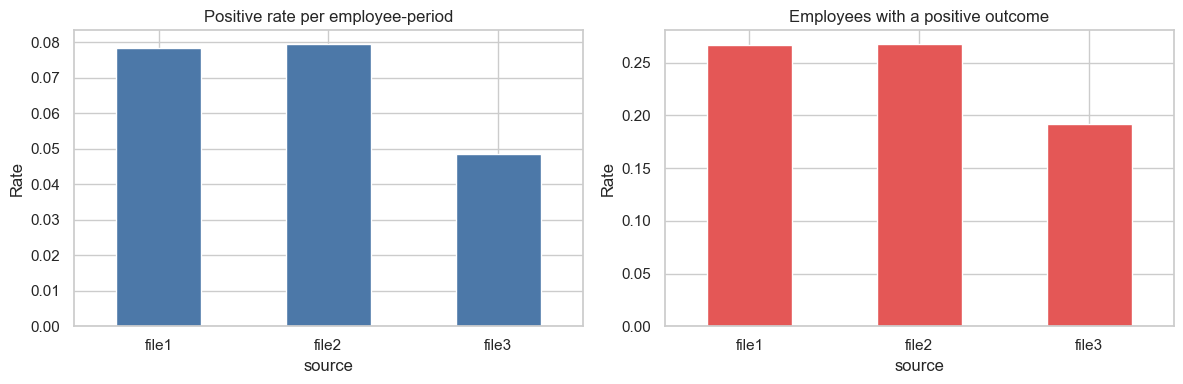

In [17]:
ordered = united_df.sort_values(["fictive_id", "calc_month"], kind="stable")
positive_snapshot = (
    ordered[ordered["leave_ind"].eq(1)]
    .drop_duplicates("fictive_id", keep="last")
)
positive_ids = set(positive_snapshot["fictive_id"])
negative_snapshot = (
    ordered[~ordered["fictive_id"].isin(positive_ids)]
    .drop_duplicates("fictive_id", keep="last")
)
employee_df = pd.concat([positive_snapshot, negative_snapshot], ignore_index=True)
assert employee_df["fictive_id"].is_unique
period_counts = ordered.groupby("fictive_id").size()
employee_df["n_periods"] = employee_df["fictive_id"].map(period_counts)
employee_df["manager_changes_per_interval"] = (
    employee_df["count_managers"] / employee_df["n_periods"].sub(1).clip(lower=1)
)

employee_summary = employee_df.groupby("source")["leave_ind"].agg(
    employees="size", leavers="sum", employee_turnover_rate="mean"
)
row_summary = united_df.groupby("source")["leave_ind"].agg(
    rows="size", positive_rows="sum", row_positive_rate="mean"
)
display(row_summary.join(employee_summary))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
row_summary["row_positive_rate"].plot.bar(ax=axes[0], color="#4c78a8", title="Positive rate per employee-period")
employee_summary["employee_turnover_rate"].plot.bar(ax=axes[1], color="#e45756", title="Employees with a positive outcome")
for ax in axes:
    ax.set_ylabel("Rate")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Interpretation.** Positive employee-period rates are 7.83%, 7.94%, and 4.86% in files 1–3; employee-level rates are 26.70%, 26.73%, and 19.17%. File 3 therefore has both lower prevalence and longer average histories. Its different baseline means final evaluation should include calibration and top-k metrics, not only threshold metrics. File 3 contains 153 positive rows from 152 employees because one employee has two positive periods.

## 4. Helper functions for statistical tests

- **Benjamini–Hochberg (BH):** controls the expected false-discovery rate when many hypotheses are tested. Use `p_BH < 0.05` instead of unadjusted p-values for the test families below.
- **Cramér's V:** measures association strength between categorical variables from 0 (none) to 1 (strong). Unlike a p-value, it describes effect size.
- **Rank-biserial correlation:** effect size for a Mann–Whitney test, from −1 to 1. Positive values below mean that leavers tend to have larger values.

In [18]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p), np.nan)
    valid = np.isfinite(p)
    values = p[valid]
    if not len(values):
        return adjusted
    order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    restored = np.empty(len(values))
    restored[order] = np.clip(ranked, 0, 1)
    adjusted[valid] = restored
    return adjusted


def cramers_v(table):
    table = np.asarray(table)
    if table.size == 0 or table.sum() == 0 or min(table.shape) < 2:
        return np.nan
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    return np.sqrt(chi2 / (table.sum() * min(table.shape[0] - 1, table.shape[1] - 1)))


def rank_biserial_from_u(u_statistic, n_stayed, n_left):
    # U is computed for the stayed group. Positive means the left group tends higher.
    return 1 - (2 * u_statistic) / (n_stayed * n_left)

## 5. Missingness analysis

First, missingness rates are described by source. Formal missingness tests use one record per employee:

- **Chi-square test:** checks whether two categorical variables, such as source and missing/not-missing, are independent.
- **Fisher's exact test:** replaces chi-square for sparse 2×2 tables and tests the same independence question exactly.

These tests identify associations; they cannot prove why values are missing or establish MCAR/MAR/MNAR by themselves.

source,file1,file2,file3
Derug,100.0000,100.0000,100.0000
salary_change,17.0600,78.6600,13.5700
stdevp_Payment,0.1800,75.1100,0.6000
Median_Payment,0.1800,75.1100,0.6000
avg_Payment,0.1800,75.1100,0.6000
tafkidCode,32.9000,7.7000,1.6800
contract_type,0.6100,5.2900,30.7900
avg_illness,0.0500,4.6000,0.0000
stdevp_illness,0.0500,4.6000,0.0000
Median_illness,0.0500,4.6000,0.0000


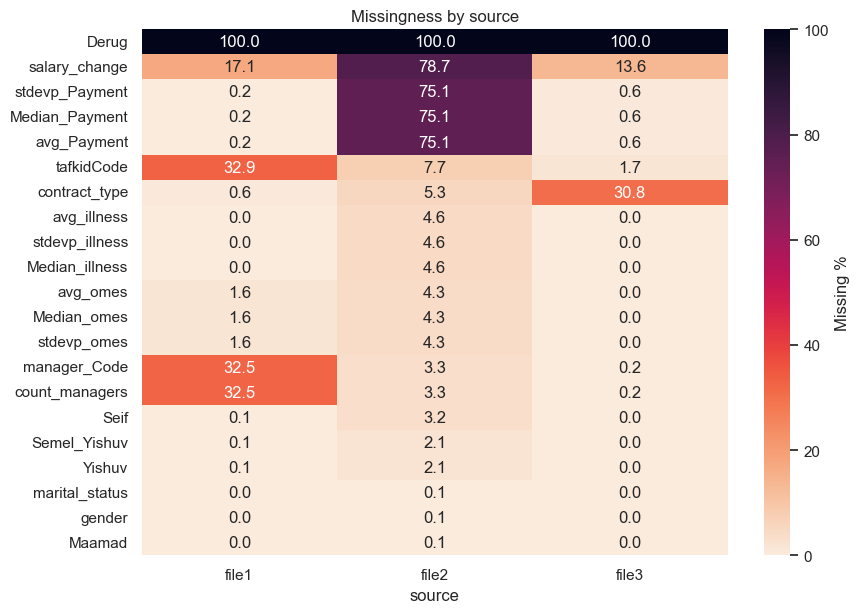

In [19]:
excluded_from_missingness = {
    "aziva_kod", "aziva_date", "aziva_year", "leave_ind",
    "fictive_employee", "fictive_id", "source",
}
candidate_columns = [
    c for c in united_df.columns
    if c not in excluded_from_missingness and united_df[c].isna().any()
]

missing_by_source = (
    united_df.groupby("source")[candidate_columns]
    .apply(lambda x: x.isna().mean() * 100)
    .T.sort_values("file2", ascending=False)
)
display(missing_by_source.round(2))

plt.figure(figsize=(9, max(5, len(missing_by_source) * 0.3)))
sns.heatmap(missing_by_source, annot=True, fmt=".1f", cmap="rocket_r", cbar_kws={"label": "Missing %"})
plt.title("Missingness by source")
plt.tight_layout()
plt.show()

In [20]:
source_missingness_tests = []
for feature in candidate_columns:
    table = pd.crosstab(employee_df["source"], employee_df[feature].isna())
    if table.shape[1] != 2:
        continue
    chi2, p_value, _, expected = stats.chi2_contingency(table, correction=False)
    if expected.min() < 5:
        continue
    source_missingness_tests.append({
        "feature": feature,
        "test": "chi-square",
        "p_value": p_value,
        "cramers_v": cramers_v(table),
        "minimum_expected_count": expected.min(),
    })

source_missingness_tests = pd.DataFrame(source_missingness_tests).sort_values("p_value")
source_missingness_tests["p_BH"] = benjamini_hochberg(source_missingness_tests["p_value"])
display(source_missingness_tests)

,feature,test,p_value,cramers_v,minimum_expected_count,p_BH
3,avg_Payment,chi-square,0.0000,0.7780,343.6896,0.0000
6,salary_change,chi-square,0.0000,0.6185,354.6566,0.0000
5,Median_Payment,chi-square,0.0000,0.7780,343.6896,0.0000
4,stdevp_Payment,chi-square,0.0000,0.7780,343.6896,0.0000
13,count_managers,chi-square,0.0000,0.3636,44.3743,0.0000
2,manager_Code,chi-square,0.0000,0.3623,44.5430,0.0000
1,tafkidCode,chi-square,0.0000,0.2250,76.0943,0.0000
0,contract_type,chi-square,0.0000,0.2209,30.3702,0.0000
7,avg_illness,chi-square,0.0001,0.0639,5.3991,0.0001
8,stdevp_illness,chi-square,0.0001,0.0639,5.3991,0.0001


In [21]:
target_missingness_tests = []
for source, group in employee_df.groupby("source"):
    for feature in candidate_columns:
        table = pd.crosstab(group["leave_ind"], group[feature].isna())
        if table.shape != (2, 2):
            continue
        _, _, _, expected = stats.chi2_contingency(table, correction=False)
        if expected.min() < 5:
            odds_ratio, p_value = stats.fisher_exact(table)
            test_name = "Fisher exact"
        else:
            _, p_value, _, _ = stats.chi2_contingency(table, correction=False)
            odds_ratio = np.nan
            test_name = "chi-square"
        target_missingness_tests.append({
            "source": source,
            "feature": feature,
            "test": test_name,
            "p_value": p_value,
            "cramers_v": cramers_v(table),
            "odds_ratio_if_fisher": odds_ratio,
        })

target_missingness_tests = pd.DataFrame(target_missingness_tests).sort_values("p_value")
target_missingness_tests["p_BH"] = benjamini_hochberg(target_missingness_tests["p_value"])
display(target_missingness_tests)

,source,feature,test,p_value,cramers_v,odds_ratio_if_fisher,p_BH
5,file1,manager_Code,chi-square,0.0000,0.4380,NaN,0.0000
16,file1,count_managers,chi-square,0.0000,0.4380,NaN,0.0000
4,file1,tafkidCode,chi-square,0.0000,0.4322,NaN,0.0000
34,file3,contract_type,chi-square,0.0000,0.3863,NaN,0.0000
9,file1,salary_change,chi-square,0.0000,0.1831,NaN,0.0000
40,file3,salary_change,chi-square,0.0000,0.2034,NaN,0.0000
21,file2,tafkidCode,chi-square,0.0000,0.0832,NaN,0.0001
0,file1,contract_type,chi-square,0.0023,0.0846,NaN,0.0118
17,file2,contract_type,chi-square,0.0138,0.0482,NaN,0.0594
33,file2,count_managers,Fisher exact,0.0159,0.0459,0.0000,0.0594


In [22]:
selected_missingness = [
    "avg_Payment", "salary_change", "tafkidCode", "manager_Code", "contract_type"
]
missingness_direction = (
    employee_df.groupby(["source", "leave_ind"])[selected_missingness]
    .apply(lambda frame: frame.isna().mean() * 100)
    .round(2)
)
display(missingness_direction)

avg_Payment  salary_change  tafkidCode  manager_Code  \
source leave_ind                                                         
file1  0               0.2100        18.6300      9.3700        8.7400   
       1               0.2900        36.1300     48.2700       47.6900   
file2  0              78.3100        83.0600      8.4200        0.7800   
       1              76.5000        81.8100      3.5800        0.0000   
file3  0               0.3100        13.4200      0.9400        0.1600   
       1               0.0000        32.8900      1.9700        0.0000   

                  contract_type  
source leave_ind                 
file1  0                 2.6300  
       1                 0.0000  
file2  0                 1.5200  
       1                 3.0100  
file3  0                 6.8600  
       1                40.1300

**Interpretation.** Missingness is strongly source-dependent. Payment summaries are missing for 75.11% of file 2 but at most 0.60% of files 1 and 3 (Cramér's V = 0.778); salary-change missingness also differs strongly (V = 0.619). Within sources, the largest turnover associations are role/manager-code missingness in file 1 (V ≈ 0.43), contract-type missingness in file 3 (40.13% for leavers versus 6.86% for stayers; V = 0.386), and salary-change missingness in files 1 and 3. Most file-2 missingness/turnover effects are small after BH correction. Missingness indicators may help, but they require leave-one-source-out validation because several primarily identify the data source.

## 6. Spearman missingness correlations

**Spearman correlation** measures monotonic association using ranks and is less sensitive to skew and outliers than Pearson correlation. Here it relates binary missingness indicators to age and tenure. Correlation does not establish a missingness mechanism, so results are shown separately by source.

In [23]:
spearman_results = []
for source, group in employee_df.groupby("source"):
    for feature in ["avg_Payment", "salary_change", "tafkidCode", "manager_Code"]:
        missing_flag = group[feature].isna().astype(int)
        if missing_flag.nunique() < 2:
            continue
        for correlate in ["age", "vetek_months"]:
            valid = group[correlate].notna()
            rho, p_value = stats.spearmanr(missing_flag[valid], group.loc[valid, correlate])
            spearman_results.append({
                "source": source,
                "missing_feature": feature,
                "correlate": correlate,
                "spearman_rho": rho,
                "p_value": p_value,
            })

spearman_results = pd.DataFrame(spearman_results).sort_values("p_value")
spearman_results["p_BH"] = benjamini_hochberg(spearman_results["p_value"])
display(spearman_results)

,source,missing_feature,correlate,spearman_rho,p_value,p_BH
3,file1,salary_change,vetek_months,-0.7278,0.0000,0.0000
11,file2,salary_change,vetek_months,-0.3782,0.0000,0.0000
19,file3,salary_change,vetek_months,-0.6269,0.0000,0.0000
9,file2,avg_Payment,vetek_months,-0.2803,0.0000,0.0000
2,file1,salary_change,age,-0.3402,0.0000,0.0000
10,file2,salary_change,age,-0.2241,0.0000,0.0000
18,file3,salary_change,age,-0.3040,0.0000,0.0000
8,file2,avg_Payment,age,-0.1316,0.0000,0.0000
12,file2,tafkidCode,age,0.1125,0.0000,0.0000
6,file1,manager_Code,age,-0.1478,0.0000,0.0000


**Interpretation.** Missing salary-change history is strongly associated with shorter tenure in every source (Spearman ρ = −0.73, −0.38, and −0.63). File-2 payment missingness also has a moderate tenure relationship (ρ = −0.28). This supports an insufficient-history explanation for some missing values, but the large source effects show that collection practices also matter. Other adjusted correlations are small or non-significant.

## 7. Numerical distributions and redundancy

**Skewness** is a descriptive measure of distribution asymmetry: values near 0 are roughly symmetric, positive values have a longer right tail, and negative values a longer left tail.

**Pearson correlation** measures linear association from −1 to 1. The matrix below is used to find redundant mean/median/variation summaries; it is not evidence that a feature causes turnover.

,count,mean,median,std,min,max,skewness
vetek_months,"4,700.0000",77.3755,40.0000,94.8515,0.0000,584.0000,1.9306
age,"4,700.0000",41.7445,41.0000,12.6798,16.0000,95.0000,0.3063
avg_Payment,"2,663.0000","11,357.0870","9,200.0000","8,307.3514",0.0000,"90,000.0000",1.8902
Median_Payment,"2,663.0000","11,325.1291","9,061.0000","8,305.6727",0.0000,"90,000.0000",1.8973
stdevp_Payment,"2,663.0000",167.8675,72.8000,357.5668,0.0000,"6,140.3978",6.4577
salary_change,"2,102.0000",481.1958,320.0000,937.7771,"-9,085.5000","12,455.0000",1.4097
avg_illness,"4,668.0000",2.8776,0.6700,4.9586,-8.9800,70.6300,3.4774
Median_illness,"4,668.0000",0.7428,0.0000,2.8288,0.0000,50.1000,5.4776
stdevp_illness,"4,668.0000",4.9070,1.3618,7.7224,0.0000,80.3155,2.9302
avg_omes,"4,637.0000",0.9524,0.9500,0.1775,0.0000,2.0800,-0.6914


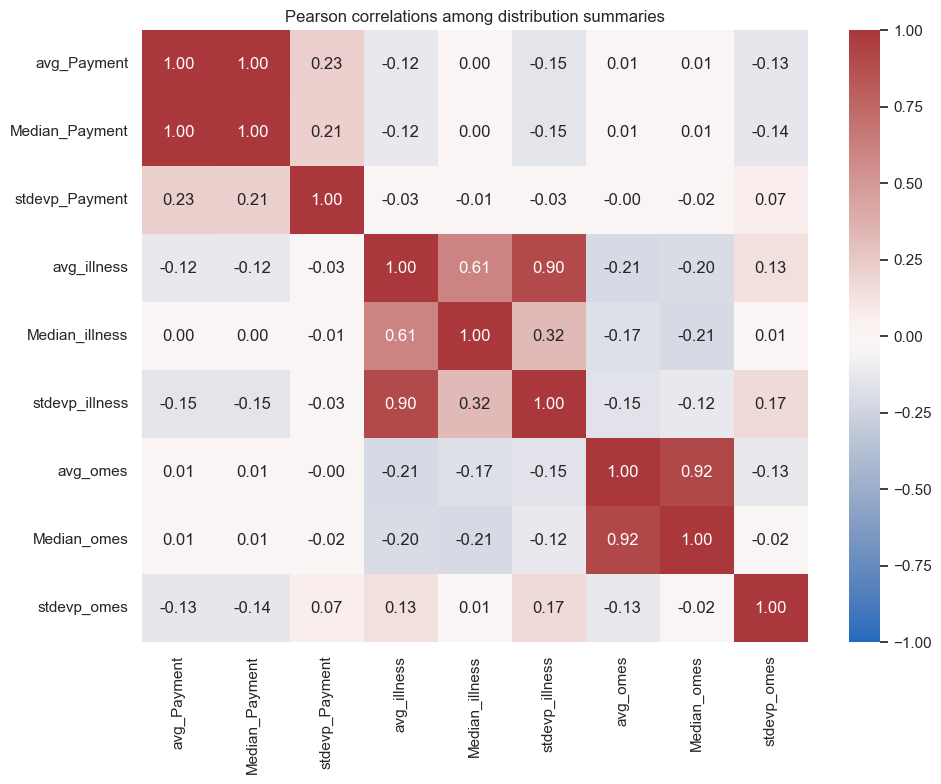

In [24]:
numeric_features = [
    "vetek_months", "age",
    "avg_Payment", "Median_Payment", "stdevp_Payment", "salary_change",
    "avg_illness", "Median_illness", "stdevp_illness",
    "avg_omes", "Median_omes", "stdevp_omes", "count_managers",
    "n_periods", "manager_changes_per_interval",
]

distribution_summary = employee_df[numeric_features].agg(["count", "mean", "median", "std", "min", "max"]).T
distribution_summary["skewness"] = employee_df[numeric_features].skew(numeric_only=True)
display(distribution_summary)

triplet_features = [
    "avg_Payment", "Median_Payment", "stdevp_Payment",
    "avg_illness", "Median_illness", "stdevp_illness",
    "avg_omes", "Median_omes", "stdevp_omes",
]
pearson_matrix = employee_df[triplet_features].corr(method="pearson")
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Pearson correlations among distribution summaries")
plt.tight_layout()
plt.show()

### Domain-value audit

The checks below flag values that need confirmation from the data owner; they do not automatically delete or correct records. A flagged value may be invalid, a legitimate edge case, or evidence that the feature has a different meaning than its name suggests.

In [25]:
domain_checks = {
    "negative average illness": united_df["avg_illness"].lt(0),
    "non-positive average payment": united_df["avg_Payment"].le(0),
    "non-positive average workload": united_df["avg_omes"].le(0),
    "age below 18": united_df["age"].lt(18),
    "age above 75": united_df["age"].gt(75),
    "negative tenure": united_df["vetek_months"].lt(0),
}
domain_audit = pd.DataFrame({
    name: flag.groupby(united_df["source"]).sum()
    for name, flag in domain_checks.items()
}).T.astype(int)
display(domain_audit)

payment_similarity = employee_df[["avg_Payment", "Median_Payment"]].dropna()
print(
    "Average/median payment Pearson correlation:",
    round(payment_similarity.corr().iloc[0, 1], 4),
)

source,file1,file2,file3
negative average illness,0,9,5
non-positive average payment,0,136,0
non-positive average workload,0,3,1
age below 18,0,10,1
age above 75,8,21,10
negative tenure,0,0,0


Average/median payment Pearson correlation: 0.9995


**Interpretation.** Most continuous features are strongly skewed, especially variability measures. Average and median payment are nearly duplicates (`r=0.9995`); illness mean/standard deviation and workload mean/median are also highly correlated. The audit found 14 negative average-illness values, 136 non-positive payment values—all in file 2—four non-positive workload values, and age values outside 18–75. Their business definitions should be confirmed before cleaning. Correlated summaries can remain for tree-model experiments, but final importance should use grouped/permutation methods because importance will be shared across redundant features.

## 8. Numerical turnover comparisons

The **Mann–Whitney U test** asks whether two independent groups tend to have different distributions without assuming normality. Tests are run separately by source on one snapshot per employee. Rank-biserial correlation supplies effect size, and BH-adjusted p-values handle multiple testing.

,source,feature,n_stayed,n_left,stayed_median,left_median,rank_biserial,p_value,p_BH
28,file2,n_periods,1913,698,4.0000,2.0000,-0.5516,0.0000,0.0000
13,file1,n_periods,950,346,4.0000,1.0000,-0.6137,0.0000,0.0000
43,file3,n_periods,641,152,6.0000,2.0000,-0.6773,0.0000,0.0000
16,file2,age,1913,698,40.0000,33.0000,-0.2928,0.0000,0.0000
0,file1,vetek_months,950,346,48.0000,18.5000,-0.3509,0.0000,0.0000
32,file3,avg_Payment,639,152,"11,950.0000","7,600.0000",-0.4782,0.0000,0.0000
1,file1,age,950,346,50.0000,40.0000,-0.3294,0.0000,0.0000
27,file2,count_managers,1898,698,1.0000,0.0000,-0.2174,0.0000,0.0000
21,file2,avg_illness,1895,686,0.2200,0.5600,0.2285,0.0000,0.0000
33,file3,Median_Payment,639,152,"11,920.0000","7,643.5000",-0.4678,0.0000,0.0000


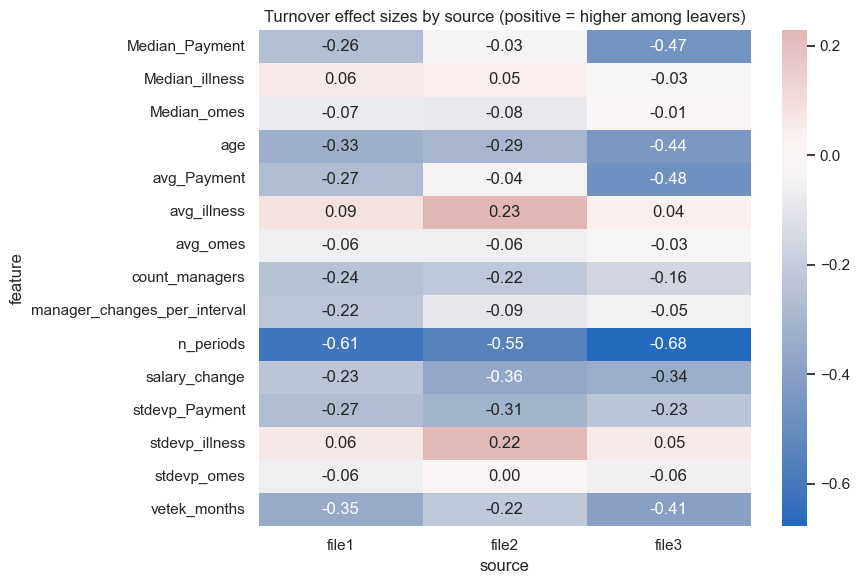

In [26]:
numeric_test_results = []
for source, group in employee_df.groupby("source"):
    for feature in numeric_features:
        stayed = pd.to_numeric(group.loc[group["leave_ind"].eq(0), feature], errors="coerce").dropna()
        left = pd.to_numeric(group.loc[group["leave_ind"].eq(1), feature], errors="coerce").dropna()
        if min(len(stayed), len(left)) < 2:
            continue
        u_stat, p_value = stats.mannwhitneyu(stayed, left, alternative="two-sided")
        numeric_test_results.append({
            "source": source,
            "feature": feature,
            "n_stayed": len(stayed),
            "n_left": len(left),
            "stayed_median": stayed.median(),
            "left_median": left.median(),
            "rank_biserial": rank_biserial_from_u(u_stat, len(stayed), len(left)),
            "p_value": p_value,
        })

numeric_test_results = pd.DataFrame(numeric_test_results).sort_values("p_value")
numeric_test_results["p_BH"] = benjamini_hochberg(numeric_test_results["p_value"])
display(numeric_test_results)

plot_data = numeric_test_results.pivot(index="feature", columns="source", values="rank_biserial")
plt.figure(figsize=(9, 6))
sns.heatmap(plot_data, annot=True, fmt=".2f", center=0, cmap="vlag")
plt.title("Turnover effect sizes by source (positive = higher among leavers)")
plt.tight_layout()
plt.show()

**Interpretation.** Younger age and shorter tenure are consistent moderate signals across all sources. Lower salary level is strong in files 1 and 3 but not file 2, where 75% of payment history is missing. Lower salary change is consistent across all sources among observed cases. Illness level is meaningful mainly in file 2, while workload-level effects are small or inconsistent.

The strongest result is fewer total periods for leavers (rank-biserial −0.55 to −0.68). This is primarily an observation-window warning: employees who leave stop accumulating records. Total lifetime period count must not be used directly. At each prediction row, use only prior-period count and available history. Lower payment variability and fewer managers are also partly maturity-driven; normalizing manager changes reduces and destabilizes that association.

## 9. Categorical turnover comparisons

Categories with fewer than 10 employees within a source are combined as `Other`. Chi-square or Fisher's exact tests assess association with turnover, while Cramér's V reports strength. Tests remain associative and do not imply that changing a category would change turnover.

In [27]:
categorical_features = [
    "gender", "contract_type", "marital_status", "Seif", "Maamad",
    "Tafkid", "Maneger", "Mahala", "WorkHours", "Sahar",
    "MZV_Flag", "hedrut", "children",
]

categorical_test_results = []
for source, group in employee_df.groupby("source"):
    for feature in categorical_features:
        values = group[feature].astype("string").fillna("Missing")
        counts = values.value_counts()
        collapsed = values.where(values.map(counts).ge(10), "Other")
        table = pd.crosstab(collapsed, group["leave_ind"])
        if table.shape[0] < 2 or table.shape[1] < 2:
            continue
        _, chi_p, _, expected = stats.chi2_contingency(table, correction=False)
        if table.shape == (2, 2) and expected.min() < 5:
            _, p_value = stats.fisher_exact(table)
            test_name = "Fisher exact"
        elif expected.min() < 5:
            # A sparse larger table does not meet the chi-square approximation well.
            continue
        else:
            p_value = chi_p
            test_name = "chi-square"
        categorical_test_results.append({
            "source": source,
            "feature": feature,
            "test": test_name,
            "categories_after_collapse": table.shape[0],
            "cramers_v": cramers_v(table),
            "p_value": p_value,
        })

categorical_test_results = pd.DataFrame(categorical_test_results).sort_values("p_value")
categorical_test_results["p_BH"] = benjamini_hochberg(categorical_test_results["p_value"])
display(categorical_test_results)

,source,feature,test,categories_after_collapse,cramers_v,p_value,p_BH
4,file1,Tafkid,chi-square,2,0.4032,0.0000,0.0000
22,file3,contract_type,chi-square,4,0.4021,0.0000,0.0000
13,file2,Tafkid,chi-square,2,0.1537,0.0000,0.0000
14,file2,Maneger,chi-square,2,0.0935,0.0000,0.0000
8,file1,Sahar,chi-square,2,0.1189,0.0000,0.0001
2,file1,marital_status,chi-square,4,0.1316,0.0001,0.0003
15,file2,Mahala,chi-square,2,0.0785,0.0001,0.0003
5,file1,Maneger,chi-square,2,0.1037,0.0002,0.0007
1,file1,contract_type,chi-square,4,0.1193,0.0004,0.0012
24,file3,Maneger,chi-square,2,0.1192,0.0008,0.0025


In [28]:
directional_categorical_features = ["Tafkid", "Maneger", "contract_type"]
categorical_rate_tables = []
for source, group in employee_df.groupby("source"):
    for feature in directional_categorical_features:
        values = group[feature].astype("string").fillna("Missing")
        counts = values.value_counts()
        collapsed = values.where(values.map(counts).ge(10), "Other")
        summary = (
            pd.DataFrame({"category": collapsed, "leave_ind": group["leave_ind"].to_numpy()})
            .groupby("category")["leave_ind"]
            .agg(turnover_rate="mean", employees="size")
            .reset_index()
        )
        summary.insert(0, "feature", feature)
        summary.insert(0, "source", source)
        categorical_rate_tables.append(summary)

categorical_rate_summary = pd.concat(categorical_rate_tables, ignore_index=True)
display(categorical_rate_summary)

,source,feature,category,turnover_rate,employees
0,file1,Tafkid,0,0.3862,896
1,file1,Tafkid,1,0.0000,400
2,file1,Maneger,0,0.2810,1185
3,file1,Maneger,1,0.1171,111
4,file1,contract_type,Global,0.2159,389
5,file1,contract_type,Hourly,0.2889,180
6,file1,contract_type,Missing,0.0000,25
7,file1,contract_type,Monthly,0.2991,702
8,file2,Tafkid,0,0.2552,2531
9,file2,Tafkid,1,0.6500,80


**Interpretation.** `Tafkid` has the largest categorical effects, but its direction reverses: value 1 has 0% turnover in file 1, 65% in file 2, and 14% in file 3. It is not portable until its source-specific meaning is verified. `Maneger=1` is associated with lower turnover in all three files, although this may reflect seniority or role rather than a management effect. File-3 contract type is dominated by the `Missing` category (58.1% turnover), so its large V=0.402 is mainly a data-availability signal. Gender and most small flags show weak or inconsistent effects.

## 10. External-source shift: files 1+2 versus file 3

- **Kolmogorov–Smirnov (KS) test:** detects any difference between two numerical distributions. Its statistic ranges from 0 to 1; larger values mean greater distribution shift.
- **Standardized mean difference (SMD):** expresses a mean difference in pooled standard-deviation units. It describes magnitude and is less sample-size-dependent than a p-value.

These checks measure transportability risk between the future training and test sources.

In [29]:
train_employees = employee_df[employee_df["source"].isin(["file1", "file2"])]
test_employees = employee_df[employee_df["source"].eq("file3")]

shift_results = []
for feature in numeric_features:
    train_values = pd.to_numeric(train_employees[feature], errors="coerce").dropna()
    test_values = pd.to_numeric(test_employees[feature], errors="coerce").dropna()
    if min(len(train_values), len(test_values)) < 2:
        continue
    ks_stat, p_value = stats.ks_2samp(train_values, test_values)
    pooled_sd = np.sqrt((train_values.var(ddof=1) + test_values.var(ddof=1)) / 2)
    smd = (test_values.mean() - train_values.mean()) / pooled_sd if pooled_sd > 0 else np.nan
    shift_results.append({
        "feature": feature,
        "train_n": len(train_values),
        "file3_n": len(test_values),
        "ks_statistic": ks_stat,
        "smd_file3_minus_train": smd,
        "p_value": p_value,
    })

shift_results = pd.DataFrame(shift_results).sort_values("ks_statistic", ascending=False)
shift_results["p_BH"] = benjamini_hochberg(shift_results["p_value"])
display(shift_results)

,feature,train_n,file3_n,ks_statistic,smd_file3_minus_train,p_value,p_BH
8,stdevp_illness,3875,793,0.4814,0.5969,0.0000,0.0000
6,avg_illness,3875,793,0.4756,0.7391,0.0000,0.0000
5,salary_change,1445,657,0.3615,0.1605,0.0000,0.0000
4,stdevp_Payment,1872,791,0.3178,0.0028,0.0000,0.0000
3,Median_Payment,1872,791,0.2971,0.2745,0.0000,0.0000
2,avg_Payment,1872,791,0.2954,0.2708,0.0000,0.0000
7,Median_illness,3875,793,0.2539,0.5924,0.0000,0.0000
9,avg_omes,3844,793,0.1980,-0.3073,0.0000,0.0000
10,Median_omes,3844,793,0.1975,-0.3491,0.0000,0.0000
13,n_periods,3907,793,0.1398,0.2984,0.0000,0.0000


In [30]:
categorical_shift_results = []
shift_frame = employee_df.assign(
    source_group=np.where(employee_df["source"].eq("file3"), "file3", "file1+file2")
)
for feature in categorical_features:
    values = shift_frame[feature].astype("string").fillna("Missing")
    counts = values.value_counts()
    collapsed = values.where(values.map(counts).ge(20), "Other")
    table = pd.crosstab(collapsed, shift_frame["source_group"])
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    _, p_value, _, expected = stats.chi2_contingency(table, correction=False)
    if expected.min() < 5:
        continue
    categorical_shift_results.append({
        "feature": feature,
        "cramers_v": cramers_v(table),
        "p_value": p_value,
    })

categorical_shift_results = pd.DataFrame(categorical_shift_results).sort_values("cramers_v", ascending=False)
categorical_shift_results["p_BH"] = benjamini_hochberg(categorical_shift_results["p_value"])
display(categorical_shift_results)

,feature,cramers_v,p_value,p_BH
2,Tafkid,0.3008,0.0000,0.0000
4,Mahala,0.1032,0.0000,0.0000
0,gender,0.1006,0.0000,0.0000
1,marital_status,0.0600,0.0007,0.0017
8,children,0.0416,0.0043,0.0078
5,WorkHours,0.0196,0.1791,0.2686
6,Sahar,0.0143,0.3262,0.4194
3,Maneger,0.0118,0.4193,0.4718
7,MZV_Flag,0.0091,0.5344,0.5344


**Interpretation.** File 3 differs materially from the training sources in illness (KS ≈ 0.48; SMD 0.59–0.74), payment (KS ≈ 0.30), workload (SMD about −0.31 to −0.35), salary change, and history length. `Tafkid` also has substantial categorical source shift (V=0.301). Age and tenure shifts are smaller. These differences make file 3 a useful external test, but they also mean a good internal random split can overstate generalization.

## 11. Within-employee changes over time

For employees with at least two records, each delta is the last observed value minus the first observed value. A source-specific Mann–Whitney test compares these deltas between employees who ever leave and employees who do not. This captures change but does not yet guarantee that every last observation occurs before the prediction cutoff.

In [31]:
change_features = [
    "avg_Payment", "avg_illness", "avg_omes", "count_managers"
]

first_rows = ordered.drop_duplicates("fictive_id", keep="first").set_index("fictive_id")
last_rows = ordered.drop_duplicates("fictive_id", keep="last").set_index("fictive_id")
employee_outcome = ordered.groupby("fictive_id")["leave_ind"].max()
record_counts = ordered.groupby("fictive_id").size()

change_df = pd.DataFrame(index=employee_outcome.index)
change_df["leave_ind"] = employee_outcome
change_df["source"] = first_rows["source"]
change_df["n_periods"] = record_counts
for feature in change_features:
    change_df[f"delta_{feature}"] = (
        pd.to_numeric(last_rows[feature], errors="coerce")
        - pd.to_numeric(first_rows[feature], errors="coerce")
    )
change_df = change_df[change_df["n_periods"].ge(2)]

change_test_results = []
for source, group in change_df.groupby("source"):
    for feature in [f"delta_{name}" for name in change_features]:
        stayed = group.loc[group["leave_ind"].eq(0), feature].dropna()
        left = group.loc[group["leave_ind"].eq(1), feature].dropna()
        if min(len(stayed), len(left)) < 2:
            continue
        u_stat, p_value = stats.mannwhitneyu(stayed, left, alternative="two-sided")
        change_test_results.append({
            "source": source,
            "feature": feature,
            "n_stayed": len(stayed),
            "n_left": len(left),
            "stayed_median_delta": stayed.median(),
            "left_median_delta": left.median(),
            "rank_biserial": rank_biserial_from_u(u_stat, len(stayed), len(left)),
            "p_value": p_value,
        })

change_test_results = pd.DataFrame(change_test_results).sort_values("p_value")
change_test_results["p_BH"] = benjamini_hochberg(change_test_results["p_value"])
display(change_test_results)

,source,feature,n_stayed,n_left,stayed_median_delta,left_median_delta,rank_biserial,p_value,p_BH
5,file2,delta_avg_illness,1547,343,0.0000,0.4900,0.3662,0.0000,0.0000
8,file3,delta_avg_Payment,584,79,"1,717.3350",699.0000,-0.3201,0.0000,0.0000
0,file1,delta_avg_Payment,810,162,750.9150,228.0100,-0.2230,0.0000,0.0000
9,file3,delta_avg_illness,589,79,0.7200,3.6000,0.2807,0.0000,0.0001
7,file2,delta_count_managers,1568,343,1.0000,0.0000,-0.1213,0.0002,0.0005
10,file3,delta_avg_omes,589,79,-0.0200,-0.0700,-0.2436,0.0004,0.0009
6,file2,delta_avg_omes,1550,341,-0.0300,-0.0500,-0.1054,0.0023,0.0039
1,file1,delta_avg_illness,811,162,0.1300,2.4150,0.1455,0.0034,0.0051
4,file2,delta_avg_Payment,297,83,"2,200.0000","1,500.0000",-0.1986,0.0056,0.0074
11,file3,delta_count_managers,586,79,0.0000,0.0000,-0.1250,0.0446,0.0535


**Interpretation.** Change features are more consistent than several static levels. Leavers have a larger increase in average illness in all sources (rank-biserial 0.15, 0.37, and 0.28) and smaller payment growth in all sources (−0.22, −0.20, and −0.32). Workload declines are present in files 2 and 3 but absent in file 1; manager-count changes are weak or inconsistent. Illness and salary trajectories are therefore strong feature-engineering candidates, provided every delta or slope ends before the prediction cutoff and accounts for elapsed time.

## 12. Preprocessing recommendations established by this EDA

Exactly what this revised notebook does:

1. Preserves the supplied `leave_ind` and validates the source-specific Aziva mapping without recreating the target.
2. Prefixes employee IDs by source and avoids repeated-employee pseudoreplication in hypothesis tests.
3. Tests missingness by source and by target within source, with effect sizes and BH correction.
4. Tests numerical and categorical turnover associations separately by source.
5. Measures numerical and categorical distribution shift from files 1+2 to file 3.
6. Adds first-to-last employee change tests as an initial time-series analysis.

Recommendations for the later preprocessing script:

- Drop Aziva/date outcome metadata, identifiers, and `source` from model inputs.
- Fit every imputer, encoder, scaler, and feature selector on files 1+2 only.
- Add missingness indicators, then verify their value through grouped cross-validation and file-3 testing.
- Let XGBoost handle numerical `NaN` values natively; use train-fitted imputers for logistic regression and random forest pipelines.
- Do not interpret missing salary as zero salary.
- Use Yeo–Johnson or a signed-log transform for variables such as `salary_change` that can be negative; plain `log1p` is unsafe below −1.
- Treat correlated features as a validation/interpretability issue rather than dropping them solely from univariate p-values.
- Engineer deltas, slopes, recent-versus-prior changes, observation counts, and time since last record using information available at each prediction period only.
- Construct labels as resignation in `(t, t+12 months]`, define how right-censored periods are handled, and group all validation splits and bootstrap sampling by employee.
- Keep file 3 untouched for final external evaluation rather than using it to choose features or thresholds.
- Add leave-one-source-out validation inside the training data (`file1 → file2` and `file2 → file1`) because payment availability differs sharply between those sources.
- At each prediction row, calculate prior-period count and maturity using records available up to that row only; never use total lifetime record count. Normalize history counts such as manager changes by available intervals or elapsed time.
- Confirm negative illness, zero payment/workload, and extreme ages with the data owner before defining cleaning rules.
- Use employee-level bootstrap confidence intervals for final reported effect sizes.
- For categorical features, preserve a `Missing` level and inspect whether an apparent association is driven mostly by missingness.
- Verify the business meaning and coding consistency of `Tafkid`; its turnover direction reverses across sources.
- Treat protected/non-actionable attributes such as gender and marital status as descriptive unless there is a documented modeling and fairness rationale.

## Consolidated interpretation

The most portable candidates are age, tenure, pre-cutoff salary trajectory, and pre-cutoff illness trajectory. Salary level is useful where available but file-2 missingness requires careful imputation and ablation. Workload, manager history, `Tafkid`, contract type, and missingness indicators should be treated as conditional candidates because their effects or definitions vary by source.

The main methodological risk is time alignment. Total lifetime record count, raw manager count, and zero variability can reveal how long an employee remained observable rather than a genuine precursor to resignation. Preprocessing should construct each employee-period row using history available at time *t*, label resignation in *(t, t+12 months]*, and handle periods without sufficient future follow-up explicitly. With that rule in place, the EDA is sufficient to move to preprocessing; bootstrap confidence intervals can be added later for final reporting rather than blocking model development.